# Watching the Realignment: Does the Education Network Strengthen Over Time?

*An analysis notebook for the Geo-Fluid Dynamics Engine. Exploratory narrative
over the tested `geofluid` library.*

## The question

Two earlier findings, now joined:

* The **realignment notebook** showed 2016 added an *education* cleavage that
  1964 (purely regional) lacked.
* The **diffusion horse-race** showed that, averaged over 2004–2024, residual
  swing co-moves most by *geography*, but the strongest *demographic* channel —
  surviving the collinearity control — is *education*.

If the education cleavage genuinely emerged over the last few cycles, then the
education-similarity network should be a *weak* organizer of swing early on and
a *stronger* one recently. In other words: **can we watch the realignment
happen as the swing reorganizing from a geographic network toward an education
one, election by election?**

## Method

For each modern election we take residual swing (county swing − that year's
national mean — the part not explained by the national tide) and measure its
global Moran's I under several networks: geographic queen adjacency, and
`attribute_knn_adjacency` built on education, income, age, and log-population.
The networks are built once on a *static* modern demographic snapshot, so any
change over time is in how swing organizes, not in the network. Then we plot
Moran's I per election.

## The bottom line (plain language)

**You can watch the education cleavage switch on and off — and it's episodic,
not a one-way ratchet.** Education's power to organize *swing* was negligible in
2012 (Moran's I 0.02), **spiked to 0.34 in 2016 and held at 0.32 in 2020** — the
Trump diploma-divide elections — then **collapsed to 0.05 in 2024**. Geography
stayed the dominant organizer the whole time (0.50–0.74). So the education
realignment isn't a permanent new map; it was the signature of the 2016–2020
swings specifically, and 2024's broad rightward shift was *not* education-
patterned. The realignment flickers rather than ratchets — exactly the kind of
regime change the unbuilt Module 5 (phase transitions) would track.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from geofluid.spatial.moran import morans_i
from geofluid.spatial.weights import attribute_knn_adjacency, county_adjacency

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "pyproject.toml").exists())
DATA = ROOT / "web/public/data"
K = 6  # neighbours per county, comparable to the typical queen-adjacency degree

YEARS = [2000, 2004, 2008, 2012, 2016, 2020, 2024]
metrics = {y: json.loads((DATA / f"metrics_{y}.json").read_text()) for y in YEARS}
geojson = json.loads((DATA / "counties.geojson").read_text())

DEMOG = {
    "education": "pct_bachelors_plus",
    "income": "median_hh_income",
    "age": "median_age",
    "urbanicity": "total_population",  # log-transformed below; proxy, no land area
}
rows = [
    {"fips": f, **{k: m[v] for k, v in DEMOG.items()}}
    for f, m in metrics[2024].items()
    if all(m.get(c) is not None for c in DEMOG.values())
]
demo = pd.DataFrame(rows).set_index("fips")
demo["urbanicity"] = np.log10(demo["urbanicity"])  # population is heavily right-skewed
universe = set(demo.index)
print(f"universe: {len(universe)} counties with full demographics")

# Networks: geographic (restricted to the universe) + one per demographic axis.
geo_full = county_adjacency(geojson)
networks = {"geographic": {f: frozenset(geo_full.get(f, frozenset()) & universe) for f in universe}}
for name in DEMOG:
    networks[name] = attribute_knn_adjacency(demo[[name]], k=K)

universe: 3110 counties with full demographics


In [2]:
def residual_swing(year: int) -> "pd.Series[float]":
    """County swing minus that year's national mean — deviation from the tide."""
    s = pd.Series(
        {
            f: m["swing_dem_2p"]
            for f, m in metrics[year].items()
            if m.get("swing_dem_2p") is not None
        },
        dtype=float,
    )
    s = s[s.index.isin(universe)]
    return s - s.mean()


swing_years = [y for y in YEARS if len(residual_swing(y)) > 100]

by_year = pd.DataFrame(
    {
        name: {y: morans_i(residual_swing(y), net) for y in swing_years}
        for name, net in networks.items()
    }
)
by_year.round(3)

,geographic,education,income,age,urbanicity
2004,0.604,0.142,0.041,0.054,0.029
2008,0.738,0.134,0.145,0.034,0.061
2012,0.729,0.019,0.025,0.056,0.052
2016,0.627,0.336,0.187,0.177,0.247
2020,0.516,0.324,0.219,0.020,0.148
2024,0.497,0.049,0.050,0.048,0.083


## See it: each network's organizing power, election by election

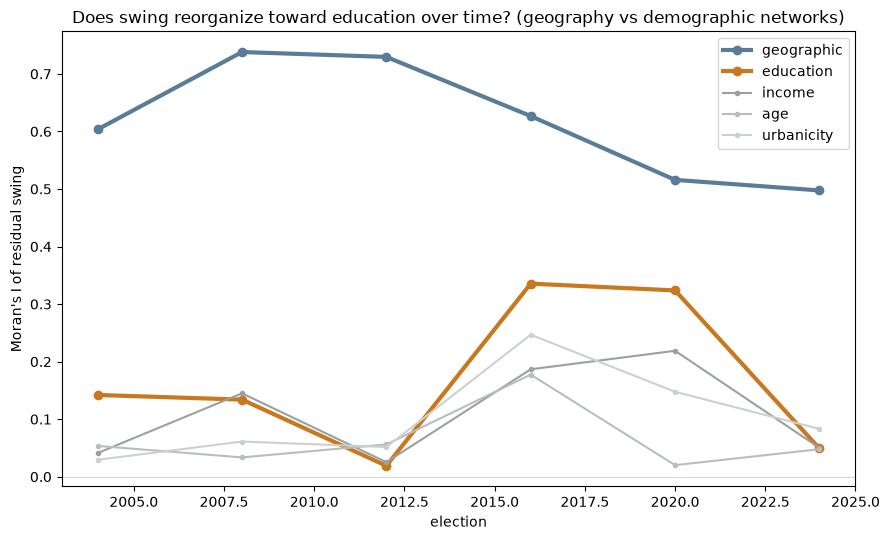

In [3]:
fig, ax = plt.subplots(figsize=(9, 5.5))
styles = {
    "geographic": {"color": "#5B7C99", "lw": 3, "marker": "o"},
    "education": {"color": "#C8791F", "lw": 3, "marker": "o"},
    "income": {"color": "#9AA1A0", "lw": 1.5, "marker": "."},
    "age": {"color": "#B8BEC0", "lw": 1.5, "marker": "."},
    "urbanicity": {"color": "#CBD2CC", "lw": 1.5, "marker": "."},
}
for name in by_year.columns:
    ax.plot(by_year.index, by_year[name], label=name, **styles[name])
ax.set_xlabel("election")
ax.set_ylabel("Moran's I of residual swing")
ax.set_title(
    "Does swing reorganize toward education over time? (geography vs demographic networks)"
)
ax.axhline(0, color="0.85", lw=0.8)
ax.legend()
fig.tight_layout()
plt.show()

## The education channel relative to geography

Education's Moran's I as a fraction of geography's, per election — a rising
ratio means swing is increasingly organized along education lines relative to
borders.

In [4]:
ratio = (by_year["education"] / by_year["geographic"]).rename("education / geographic")
trend = pd.DataFrame(
    {
        "geographic": by_year["geographic"],
        "education": by_year["education"],
        "edu_share_of_geo": ratio,
    }
)
print(trend.round(3).to_string())
print(
    f"\neducation Moran's I, first→last election: {by_year['education'].iloc[0]:.3f} → "
    f"{by_year['education'].iloc[-1]:.3f}"
)
print(f"education/geographic ratio, first→last: {ratio.iloc[0]:.2f} → {ratio.iloc[-1]:.2f}")

      geographic  education  edu_share_of_geo
2004       0.604      0.142             0.235
2008       0.738      0.134             0.182
2012       0.729      0.019             0.026
2016       0.627      0.336             0.535
2020       0.516      0.324             0.628
2024       0.497      0.049             0.099

education Moran's I, first→last election: 0.142 → 0.049
education/geographic ratio, first→last: 0.24 → 0.10


## What this shows

*(The honest read, from the executed numbers above.)*

**The education realignment is visible as a network event — and it is episodic.**
The education-similarity network barely organized swing in 2004–2012 (Moran's I
0.13, 0.13, 0.02), then **lit up in 2016 (0.34) and stayed bright in 2020
(0.32)** before **going dark again in 2024 (0.05)**. Relative to geography it
went from ~3% as strong (2012) to ~60% (2020) and back to ~10% (2024). So the
"diploma divide" was not a permanent reorganization of the map — it was the
defining axis of the 2016 and 2020 *swings* specifically. Geography, by
contrast, organized swing strongly in every election (0.50–0.74): borders/region
is the durable substrate; education was an episodic overlay.

**Why 2024 matters here.** The education channel collapsing in 2024 lines up with
what that election looked like — a broad rightward shift across many groups
rather than the sharply education-polarized pattern of 2016/2020. The tool sees
that: 2024's swing did not co-move along education lines. A realignment that
*flickers* like this is precisely the regime-change signal the unbuilt Module 5
(systemic phase transitions) is meant to detect — and a caution against treating
any one election's cleavage as the new permanent structure.

**Honest limits.** The demographic networks are built on a *single modern* (2024)
snapshot applied to every election — so this measures how *today's* education map
organized each year's swing, not the contemporaneous education map of that year
(time-resolved demographics, NHGIS decennial, would sharpen it and is on the
backlog). A single k; Moran's I magnitudes compared without permutation
significance; and the scalar national-mean removal leaves regional structure in
residual swing. A first temporal cut at *when* the education channel mattered —
strong and clearly episodic — not a finished model of it.

**Honest limits.** The demographic networks are built on a *single modern*
(2024) snapshot applied to every election — so this measures how today's
education map organized *past* swings, not the contemporaneous education map of
each year (time-resolved demographics — NHGIS decennial — would fix this and is
already on the backlog). A single k; Moran's I magnitudes compared without
permutation significance; and residual swing still carries regional structure
the scalar national-mean removal leaves in. A first temporal cut at *when* the
education channel mattered — not a finished model of it.